In [163]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [164]:
# Import data
data = pd.read_csv("./Data/laptop_data.csv")
data.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [165]:
# Remove Unnamed column
data = data.drop(columns=["Unnamed: 0"])

In [108]:
# Remove duplicate rows
data = data.drop_duplicates()
data.shape

(1274, 11)

In [109]:
# Detailed data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1274 non-null   object 
 1   TypeName          1274 non-null   object 
 2   Inches            1274 non-null   float64
 3   ScreenResolution  1274 non-null   object 
 4   Cpu               1274 non-null   object 
 5   Ram               1274 non-null   object 
 6   Memory            1274 non-null   object 
 7   Gpu               1274 non-null   object 
 8   OpSys             1274 non-null   object 
 9   Weight            1274 non-null   object 
 10  Price             1274 non-null   float64
dtypes: float64(2), object(9)
memory usage: 119.4+ KB


In [110]:
def uniquevals(col):
    print(f'Details of the particular col {col} is : {data[col].unique()}')

for col in data.columns:
    uniquevals(col)
    print("-"*100)

Details of the particular col Company is : ['Apple' 'HP' 'Acer' 'Asus' 'Dell' 'Lenovo' 'Chuwi' 'MSI' 'Microsoft'
 'Toshiba' 'Huawei' 'Xiaomi' 'Vero' 'Razer' 'Mediacom' 'Samsung' 'Google'
 'Fujitsu' 'LG']
----------------------------------------------------------------------------------------------------
Details of the particular col TypeName is : ['Ultrabook' 'Notebook' 'Netbook' 'Gaming' '2 in 1 Convertible'
 'Workstation']
----------------------------------------------------------------------------------------------------
Details of the particular col Inches is : [13.3 15.6 15.4 14.  12.  11.6 17.3 10.1 13.5 12.5 13.  18.4 13.9 12.3
 17.  15.  14.1 11.3]
----------------------------------------------------------------------------------------------------
Details of the particular col ScreenResolution is : ['IPS Panel Retina Display 2560x1600' '1440x900' 'Full HD 1920x1080'
 'IPS Panel Retina Display 2880x1800' '1366x768'
 'IPS Panel Full HD 1920x1080' 'IPS Panel Retina Display 2304x14

This dataset presents a problem in the provided information, as the RAM, Memory, Weight, Price, and Resolution columns should contain numerical values but do not.

In [111]:
data["Ram"] = data["Ram"].str.replace("GB", "").astype("int")
data["Weight"] = data["Weight"].str.replace("kg", "").astype("float")

In [112]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1274 non-null   object 
 1   TypeName          1274 non-null   object 
 2   Inches            1274 non-null   float64
 3   ScreenResolution  1274 non-null   object 
 4   Cpu               1274 non-null   object 
 5   Ram               1274 non-null   int64  
 6   Memory            1274 non-null   object 
 7   Gpu               1274 non-null   object 
 8   OpSys             1274 non-null   object 
 9   Weight            1274 non-null   float64
 10  Price             1274 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 119.4+ KB
None


### Treatment of Data

Treatment of Price Column

<Figure size 1000x700 with 0 Axes>

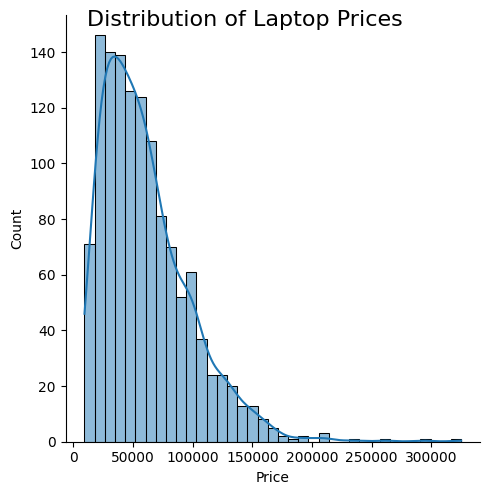

In [113]:
# Distribution of Price
plt.figure(figsize=(10,7))
g = sns.displot(data["Price"], kde=True)

plt.suptitle("Distribution of Laptop Prices", fontsize=16)
plt.show()

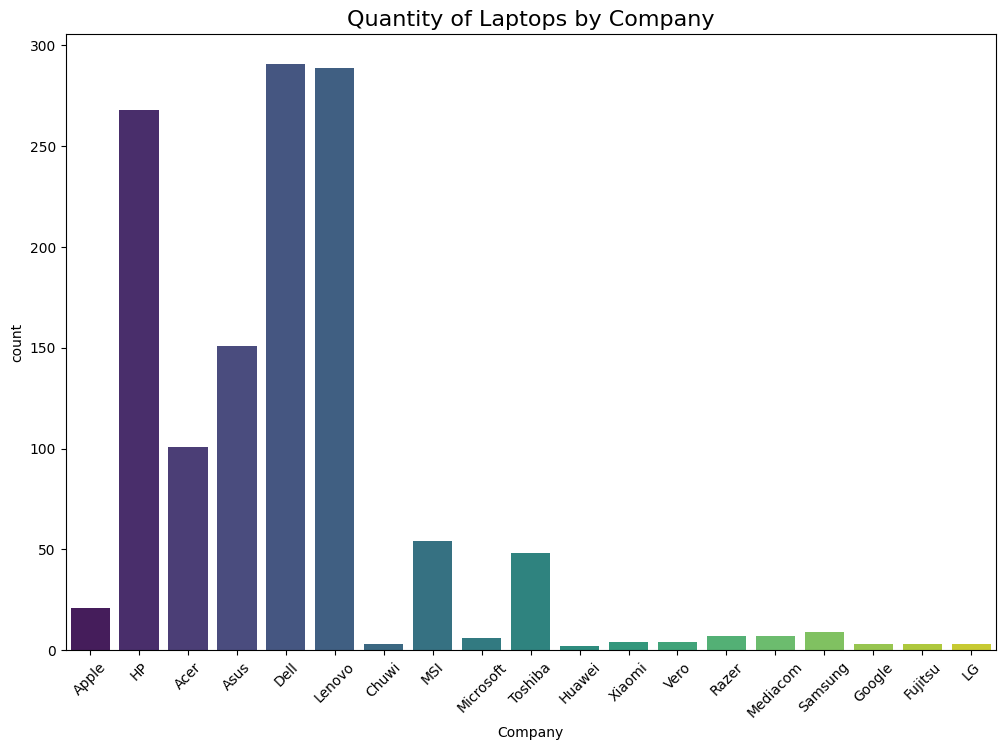

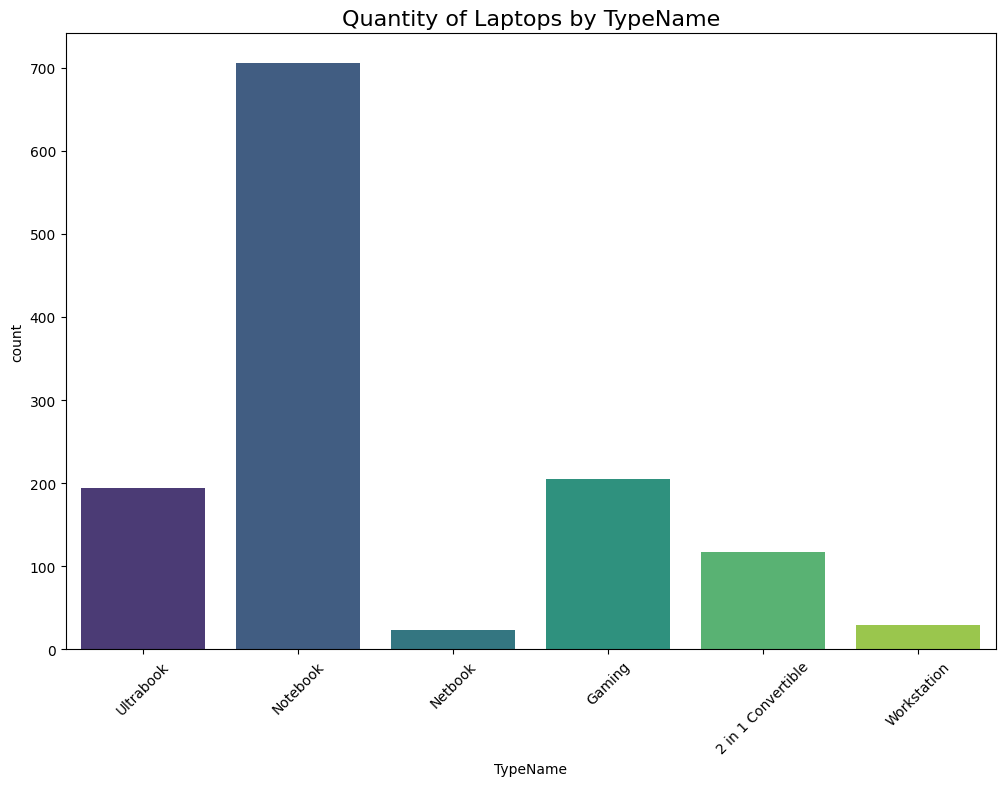

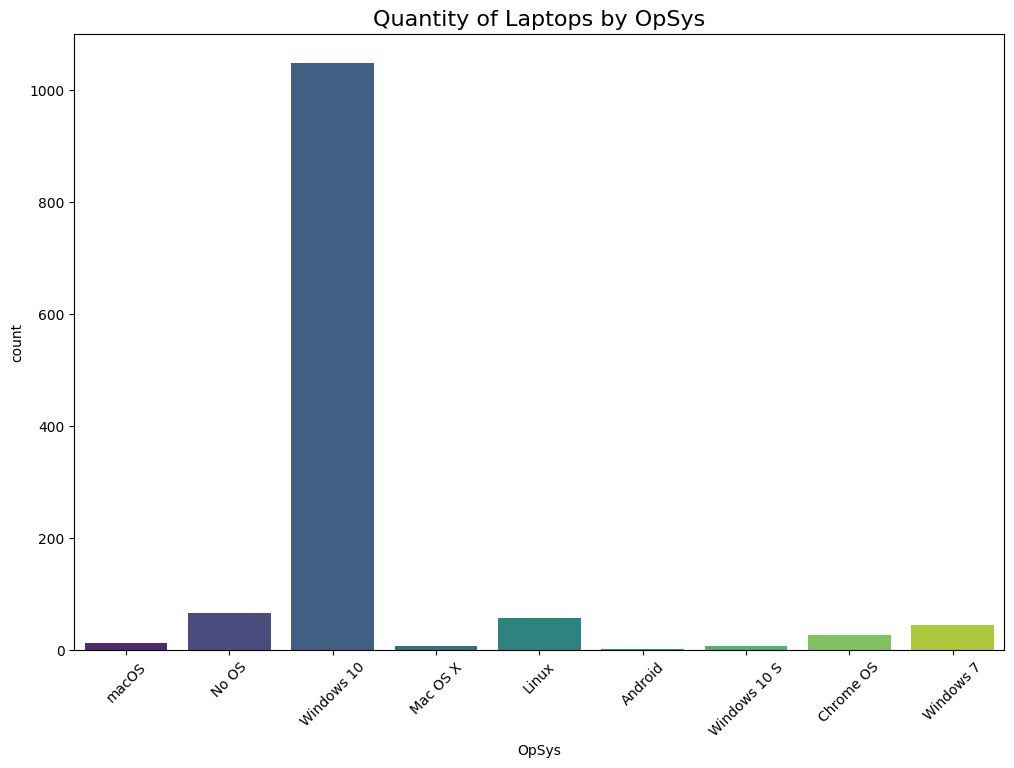

In [114]:
# Quantity of Laptops by Category
def drawplot(col):
    plt.figure(figsize=(12,8))
    sns.countplot(data=data, x=col, hue=col, palette="viridis")
    plt.xticks(rotation=45)
    plt.title(f"Quantity of Laptops by {col}", fontsize=16)
    plt.show()

Categorial_Columns = ["Company", "TypeName", "OpSys"]
for col in Categorial_Columns:
    drawplot(col)

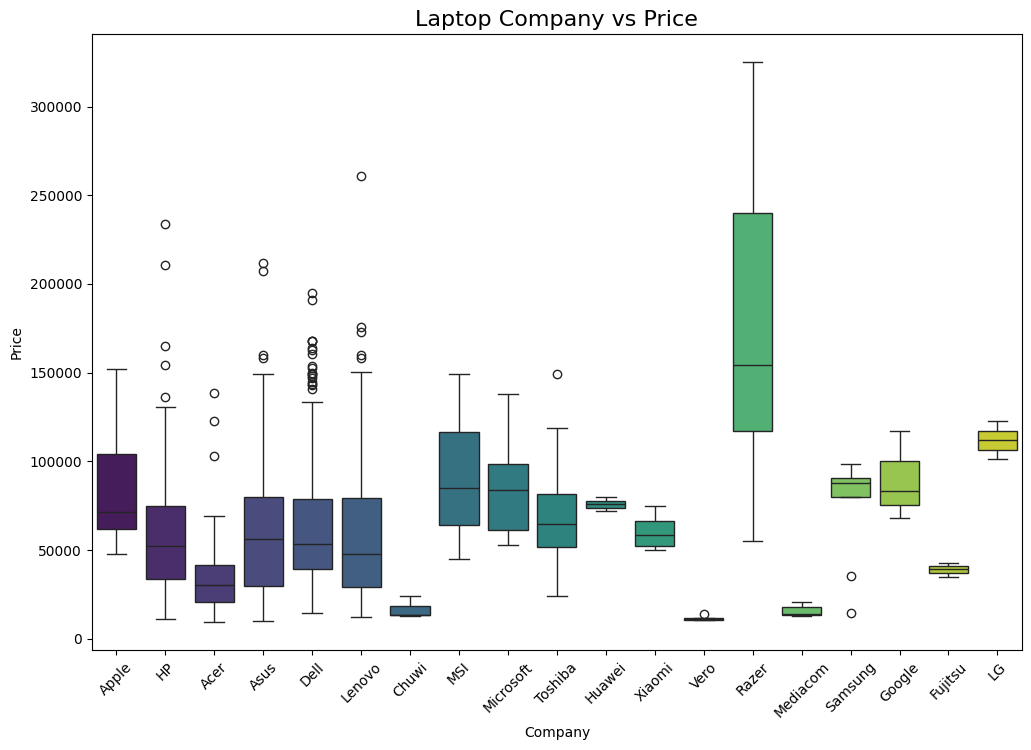

In [115]:
# laptop Company vs Price
plt.figure(figsize=(12,8))
sns.boxplot(data=data, x="Company", y="Price", hue="Company", palette="viridis")

plt.xticks(rotation=45)
plt.title("Laptop Company vs Price", fontsize=16)
plt.show()

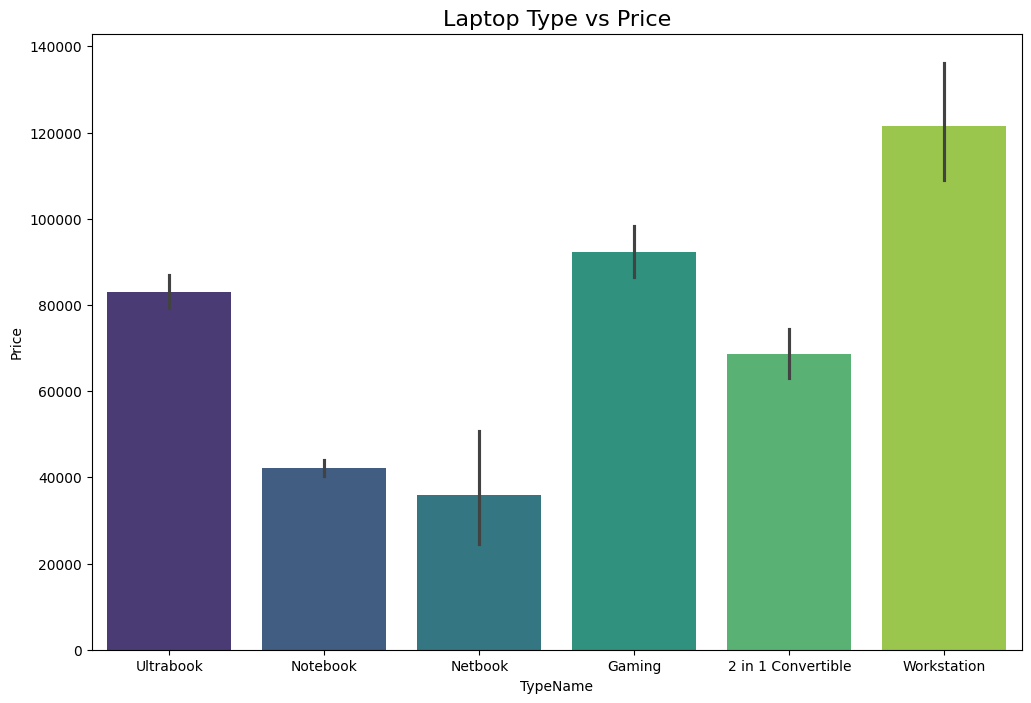

In [116]:
# Laptop Type and Price
plt.figure(figsize=(12,8))

sns.barplot(data=data, x="TypeName", y="Price", hue="TypeName", palette="viridis")
plt.title("Laptop Type vs Price", fontsize=16)

plt.show()

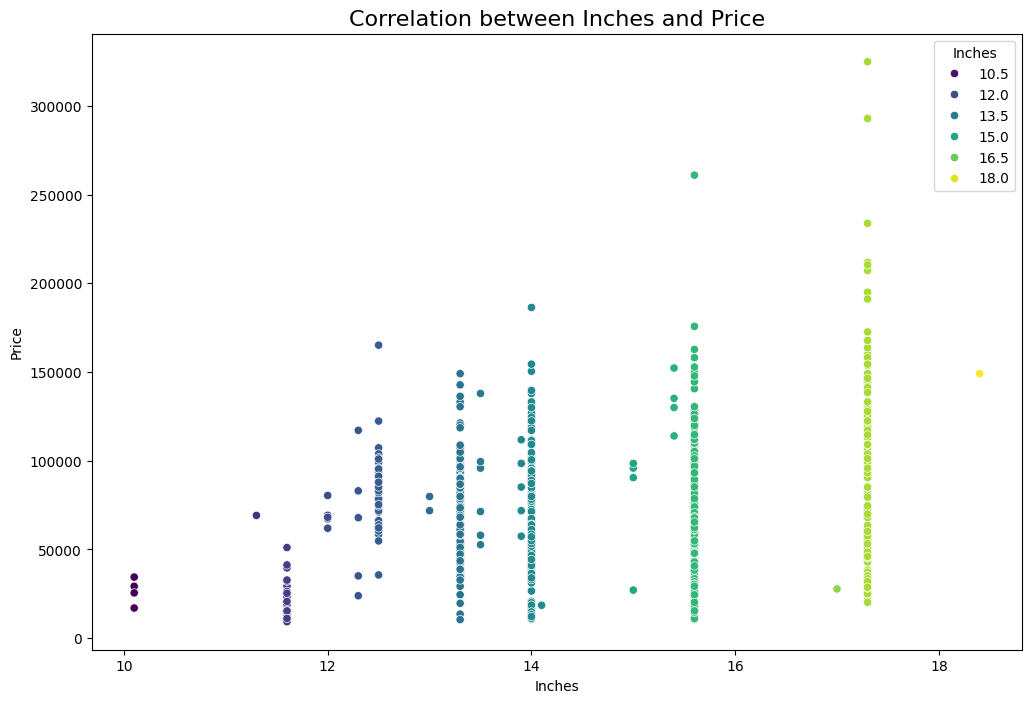

In [117]:
# Correlation between Inches and Price
plt.figure(figsize=(12,8))

sns.scatterplot(data=data, x="Inches", y="Price", hue="Inches", palette="viridis")

plt.title("Correlation between Inches and Price", fontsize=16)
plt.show()

Treatment of ScreenResolution Column

In [168]:
data["ScreenResolution"].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [118]:
# Extracting the X Ressolution and Y Resolution from the ScreenResolution column
data[['X_res', 'Y_res']] = data['ScreenResolution'].str.extract(r'(\d+)\s*[x×]\s*(\d+)')
data[['X_res', 'Y_res']] = data[['X_res', 'Y_res']].apply(pd.to_numeric)

In [119]:
data.head(4)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,2880,1800


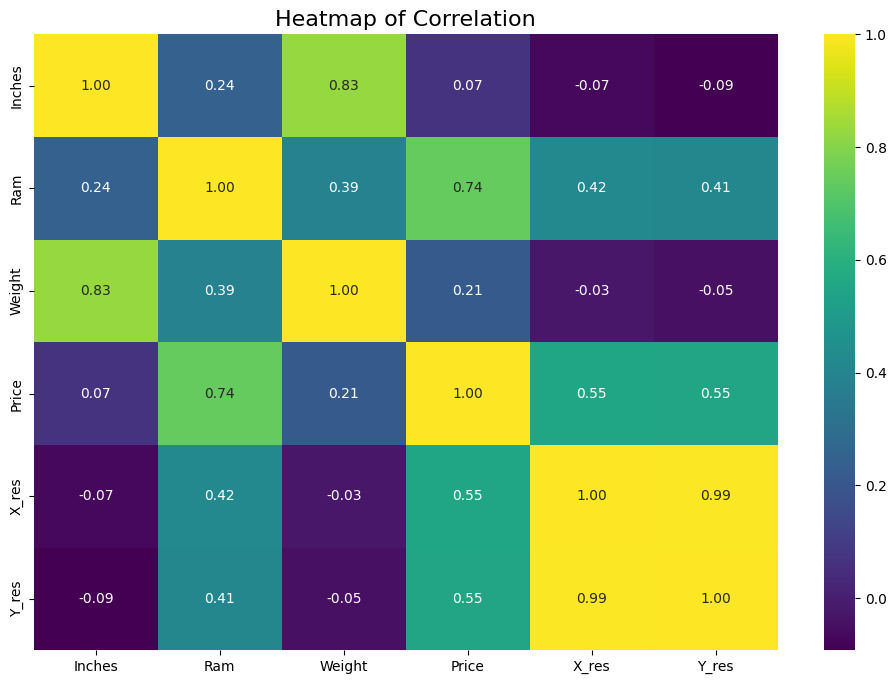

In [120]:
# Heatmap of correlation between numerical features
plt.figure(figsize=(12,8))

num_corr = data.select_dtypes(include=[np.number]).corr() # Select onlu numeric columns

sns.heatmap(num_corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Heatmap of Correlation", fontsize=16)
plt.show()

In [121]:
# Creation of New Index
data["PPI"] =  (((data['X_res']**2) + (data['Y_res']**2))**0.5 / data['Inches']).astype('float')
data.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_res,Y_res,PPI
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,2560,1600,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440,900,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,1920,1080,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,2880,1800,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,2560,1600,226.983005


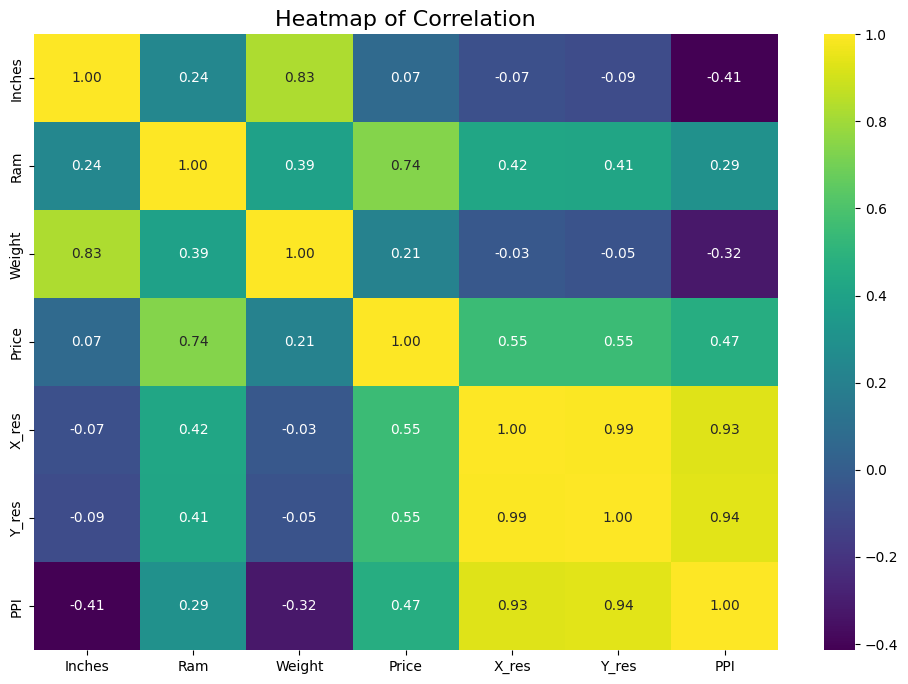

In [122]:
# Heatmap of correlation between numerical features
plt.figure(figsize=(12,8))

num_corr = data.select_dtypes(include=[np.number]).corr() # Select onlu numeric columns

sns.heatmap(num_corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Heatmap of Correlation", fontsize=16)
plt.show()

In [123]:
# Delete Unnecessary Columns
data = data.drop(columns=["ScreenResolution", "X_res", "Y_res"])
data.head()

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,PPI
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,226.983005
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,127.677940
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,141.211998
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,220.534624
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,226.983005


Treatment of CPU Column

In [167]:
data["Cpu"].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

In [124]:
# Extract the Proccesator
data["CPU_Brand"] = data["Cpu"].apply(lambda text:" ".join(text.split()[:3]))
data.head()

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,PPI,CPU_Brand
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,226.983005,Intel Core i5
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,127.677940,Intel Core i5
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,141.211998,Intel Core i5
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,220.534624,Intel Core i7
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,226.983005,Intel Core i5


In [125]:
def category_brand(text):
    if text == "Intel Core i7" or text == "Intel Core i5" or text == "Intel Core i3":
        return text
    
    else:
        if text.startswith("Intel"):
            return "Other Intel Processor"
        
        else:
            return "AMD Processor"

data["CPU_Brand"] = data["CPU_Brand"].apply(category_brand)
data.head()

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,PPI,CPU_Brand
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,226.983005,Intel Core i5
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,127.677940,Intel Core i5
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,141.211998,Intel Core i5
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,220.534624,Intel Core i7
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,226.983005,Intel Core i5


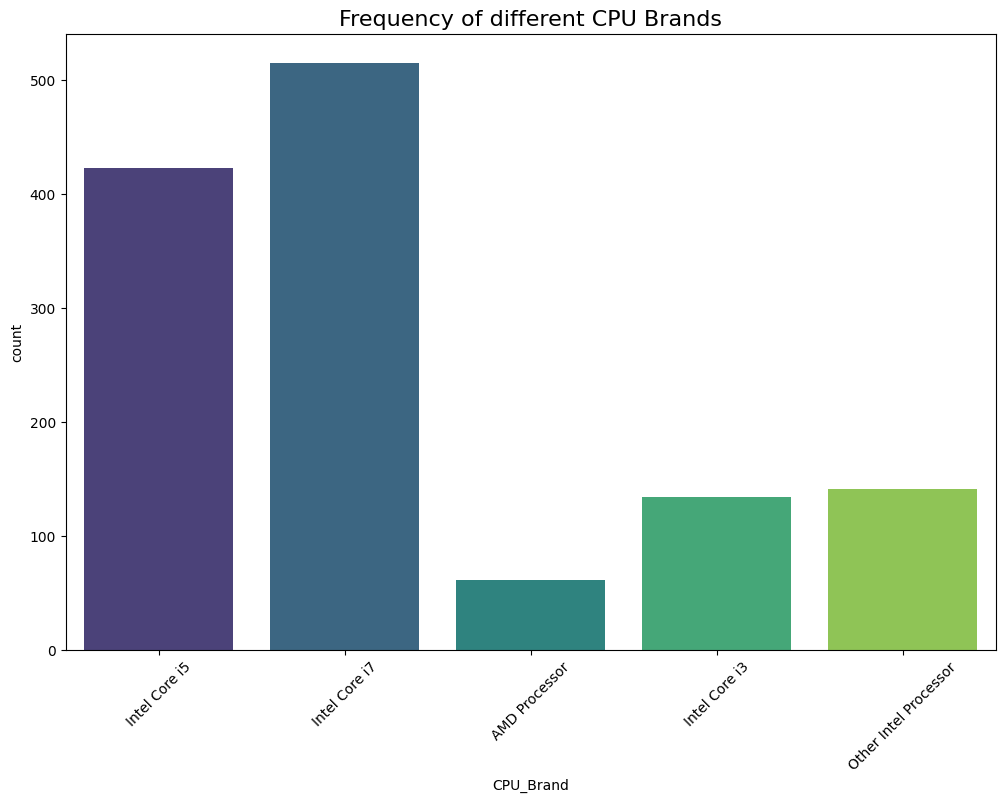

In [126]:
# Frequency of different CPU Brands
plt.figure(figsize=(12,8))

sns.countplot(data=data, x="CPU_Brand", hue="CPU_Brand", palette="viridis")
plt.xticks(rotation=45)

plt.title("Frequency of different CPU Brands", fontsize=16)
plt.show()

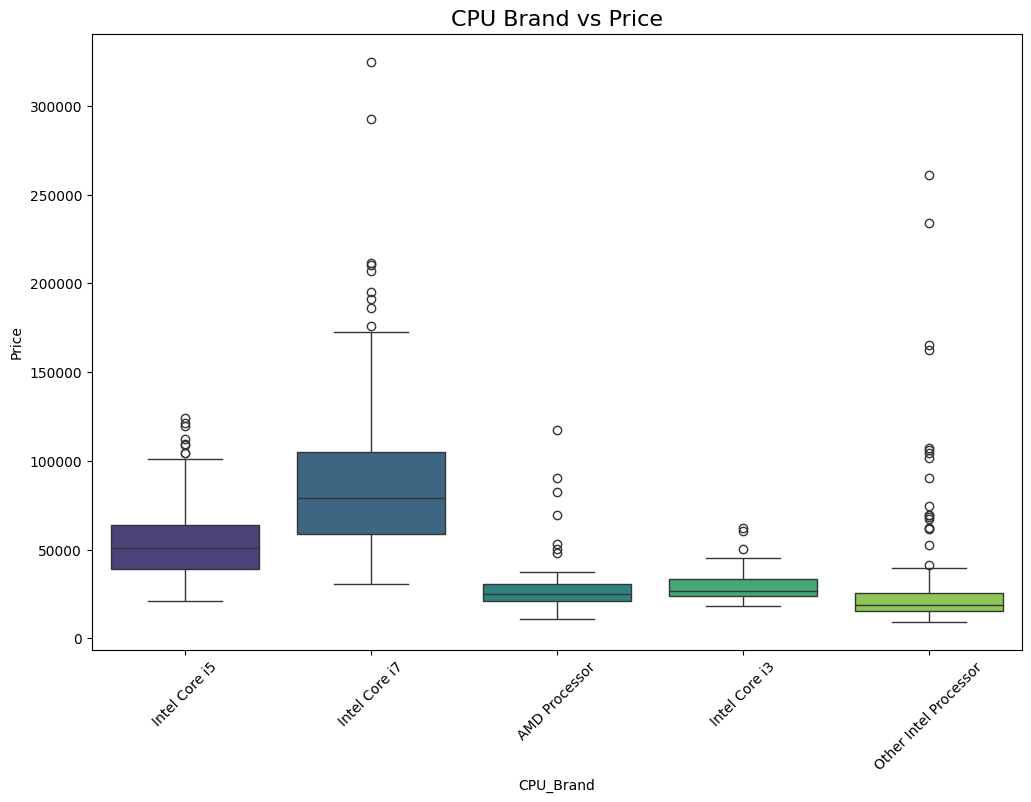

In [127]:
# Boxplot of CPU Brand vs Price
plt.figure(figsize=(12,8))

sns.boxplot(data=data, x="CPU_Brand", y="Price", hue="CPU_Brand", palette="viridis")
plt.xticks(rotation=45)

plt.title("CPU Brand vs Price", fontsize=16)
plt.show()

In [128]:
data.drop(columns=["Cpu"], inplace=True)
data.head()

,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,PPI,CPU_Brand
0,Apple,Ultrabook,13.3,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,226.983005,Intel Core i5
1,Apple,Ultrabook,13.3,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,127.677940,Intel Core i5
2,HP,Notebook,15.6,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,141.211998,Intel Core i5
3,Apple,Ultrabook,15.4,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,220.534624,Intel Core i7
4,Apple,Ultrabook,13.3,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,226.983005,Intel Core i5


Treatment of Memory Column

In [129]:
# Values of Memory Types
data["Memory"].value_counts()

Memory
256GB SSD                        412
1TB HDD                          215
500GB HDD                        123
512GB SSD                        114
128GB SSD +  1TB HDD              94
128GB SSD                         74
256GB SSD +  1TB HDD              73
32GB Flash Storage                36
2TB HDD                           16
512GB SSD +  1TB HDD              14
1TB SSD                           14
64GB Flash Storage                13
256GB SSD +  2TB HDD              10
256GB Flash Storage                8
1.0TB Hybrid                       7
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [130]:
data["Memory"] = data["Memory"].astype(str).replace("\.0", "", regex=True) # Remove .0 from the strings
data["Memory"] = data["Memory"].str.replace("GB", "") # Remove GB from the strings
data["Memory"] = data["Memory"].str.replace("TB", "000") # Convert TB to GB by multiplying by 1000

# Split the column if multiple types of memory is present
data[["Memory_1", "Memory_2"]] = data["Memory"].str.split("+", n=1, expand=True)
data.head(4)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\josec\AppData\Local\Temp\ipykernel_31632\60315438.py:1: SyntaxWarning: invalid escape sequence '\.'
  data["Memory"] = data["Memory"].astype(str).replace("\.0", "", regex=True) # Remove .0 from the strings


,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,PPI,CPU_Brand,Memory_1,Memory_2
0,Apple,Ultrabook,13.3,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,226.983005,Intel Core i5,128 SSD,None
1,Apple,Ultrabook,13.3,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,127.677940,Intel Core i5,128 Flash Storage,None
2,HP,Notebook,15.6,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,141.211998,Intel Core i5,256 SSD,None
3,Apple,Ultrabook,15.4,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,220.534624,Intel Core i7,512 SSD,None


In [131]:
def extract_size_type(column):
    result = column.str.extract(r'(\d+)\s*(.+)')
    result[0] = pd.to_numeric(result[0], errors='coerce')
    return result[0], result[1]

data['Memory_1_Size'], data['Memory_1_Type'] = extract_size_type(data['Memory_1'])
data['Memory_2_Size'], data['Memory_2_Type'] = extract_size_type(data['Memory_2'])

data['Memory_1_Type'] = data['Memory_1_Type'].str.strip()
data['Memory_2_Type'] = data['Memory_2_Type'].str.strip()

data.head()

,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,PPI,CPU_Brand,Memory_1,Memory_2,Memory_1_Size,Memory_1_Type,Memory_2_Size,Memory_2_Type
0,Apple,Ultrabook,13.3,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,226.983005,Intel Core i5,128 SSD,None,128,SSD,NaN,NaN
1,Apple,Ultrabook,13.3,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,127.677940,Intel Core i5,128 Flash Storage,None,128,Flash Storage,NaN,NaN
2,HP,Notebook,15.6,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,141.211998,Intel Core i5,256 SSD,None,256,SSD,NaN,NaN
3,Apple,Ultrabook,15.4,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,220.534624,Intel Core i7,512 SSD,None,512,SSD,NaN,NaN
4,Apple,Ultrabook,13.3,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,226.983005,Intel Core i5,256 SSD,None,256,SSD,NaN,NaN


In [132]:
all_types = []
for col in ['Memory_1_Type']:
    unique_types = data[col].dropna().unique()
    all_types.extend(unique_types)
all_types = list(set(all_types))

print("Types:", all_types)

Types: ['SSD', 'HDD', 'Flash Storage', 'Hybrid']


In [133]:
for tipo in all_types:
    data[tipo] = 0  # Inicializar con 0
    
    # Sumar Memory_1 si coincide el tipo
    mask1 = data['Memory_1_Type'] == tipo
    data.loc[mask1, tipo] = data.loc[mask1, 'Memory_1_Size']
    
    # Sumar Memory_2 si coincide el tipo (usando +=)
    mask2 = data['Memory_2_Type'] == tipo
    data.loc[mask2, tipo] += data.loc[mask2, 'Memory_2_Size']

In [134]:
data.head()

,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,PPI,...,Memory_1,Memory_2,Memory_1_Size,Memory_1_Type,Memory_2_Size,Memory_2_Type,SSD,HDD,Flash Storage,Hybrid
0,Apple,Ultrabook,13.3,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,226.983005,...,128 SSD,None,128,SSD,NaN,NaN,128,0,0,0
1,Apple,Ultrabook,13.3,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,127.677940,...,128 Flash Storage,None,128,Flash Storage,NaN,NaN,0,0,128,0
2,HP,Notebook,15.6,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,141.211998,...,256 SSD,None,256,SSD,NaN,NaN,256,0,0,0
3,Apple,Ultrabook,15.4,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,220.534624,...,512 SSD,None,512,SSD,NaN,NaN,512,0,0,0
4,Apple,Ultrabook,13.3,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,226.983005,...,256 SSD,None,256,SSD,NaN,NaN,256,0,0,0


In [135]:
data.drop(columns=["Memory", "Memory_1", "Memory_2", "Memory_1_Size", "Memory_1_Type", "Memory_2_Size", "Memory_2_Type"], inplace=True)
data.head()

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,PPI,CPU_Brand,SSD,HDD,Flash Storage,Hybrid
0,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,226.983005,Intel Core i5,128,0,0,0
1,Apple,Ultrabook,13.3,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,127.677940,Intel Core i5,0,0,128,0
2,HP,Notebook,15.6,8,Intel HD Graphics 620,No OS,1.86,30636.0000,141.211998,Intel Core i5,256,0,0,0
3,Apple,Ultrabook,15.4,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,220.534624,Intel Core i7,512,0,0,0
4,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,226.983005,Intel Core i5,256,0,0,0


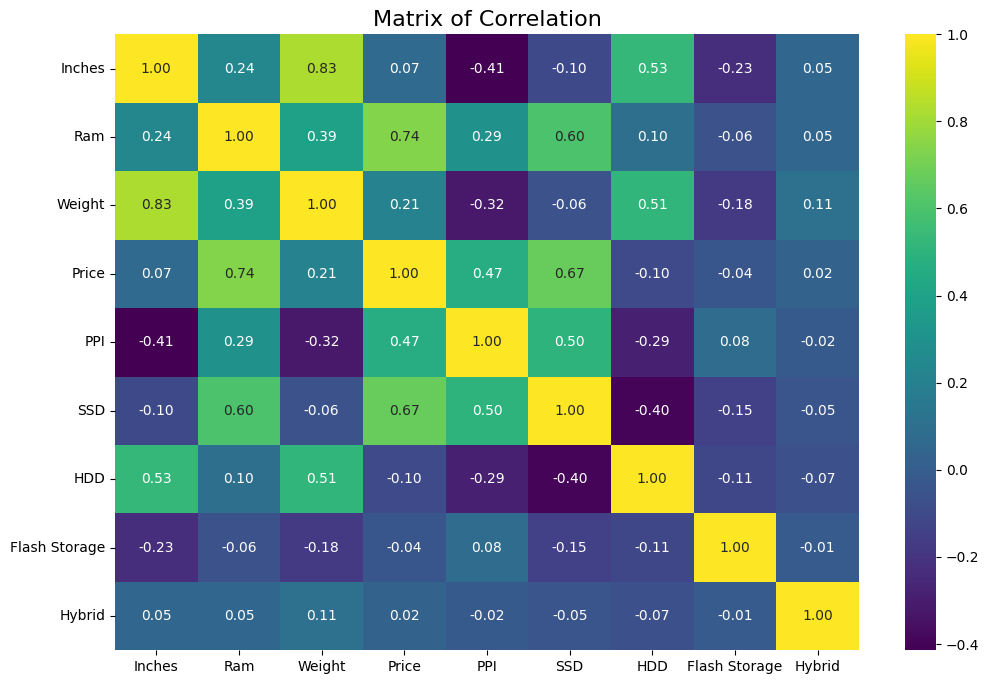

In [136]:
# Matrix of Correlation
plt.figure(figsize=(12,8))

num_corr = data.select_dtypes(include=[np.number]).corr() # Select onlu numeric columns
sns.heatmap(num_corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Matrix of Correlation", fontsize=16)
plt.show()

In [137]:
data.drop(columns=["Flash Storage", "Hybrid"], inplace=True)
data.head()

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,PPI,CPU_Brand,SSD,HDD
0,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,226.983005,Intel Core i5,128,0
1,Apple,Ultrabook,13.3,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,127.677940,Intel Core i5,0,0
2,HP,Notebook,15.6,8,Intel HD Graphics 620,No OS,1.86,30636.0000,141.211998,Intel Core i5,256,0
3,Apple,Ultrabook,15.4,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,220.534624,Intel Core i7,512,0
4,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,226.983005,Intel Core i5,256,0


Treatment of GPU Column

In [138]:
data["Gpu"].value_counts()

Gpu
Intel HD Graphics 620      279
Intel HD Graphics 520      181
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [ ]:
data["Gpu_Brand"] = data["Gpu"].apply(lambda text:text.split()[0])
data["Gpu_Brand"].value_counts()

Gpu_Brand
Intel     703
Nvidia    396
AMD       174
ARM         1
Name: count, dtype: int64

In [140]:
data = data[data["Gpu_Brand"] != "ARM"]
data.drop(columns=["Gpu"], inplace=True)

Treatment of Operating System Column

In [141]:
data["OpSys"].value_counts()

OpSys
Windows 10      1047
No OS             66
Linux             58
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

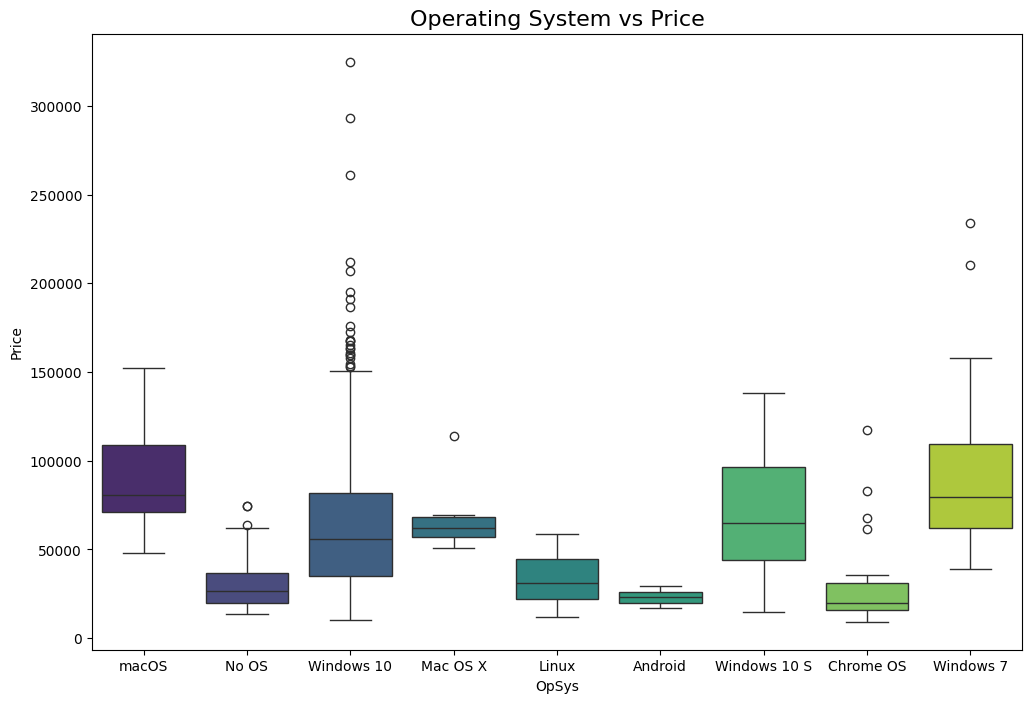

In [142]:
# Box Graph
plt.figure(figsize=(12,8))

sns.boxplot(data=data, x="OpSys", y= "Price", hue="OpSys", palette="viridis")
plt.title("Operating System vs Price", fontsize=16)

plt.show()

In [143]:
data["OpSys"].unique()

array(['macOS', 'No OS', 'Windows 10', 'Mac OS X', 'Linux', 'Android',
       'Windows 10 S', 'Chrome OS', 'Windows 7'], dtype=object)

In [144]:
def category_system(text):
    if text == "Windows 10" or text == "Windows 7" or text == "Windows 11":
        return "Windows"
    
    elif text == "Mac OS X" or text == "macOS":
        return "Mac"
    
    elif text == "Linux":
        return "Linux"
    else:
        return "Other OS"
    
data["OpSys"] = data["OpSys"].apply(category_system)
data["OpSys"].value_counts()

OpSys
Windows     1092
Other OS     102
Linux         58
Mac           21
Name: count, dtype: int64

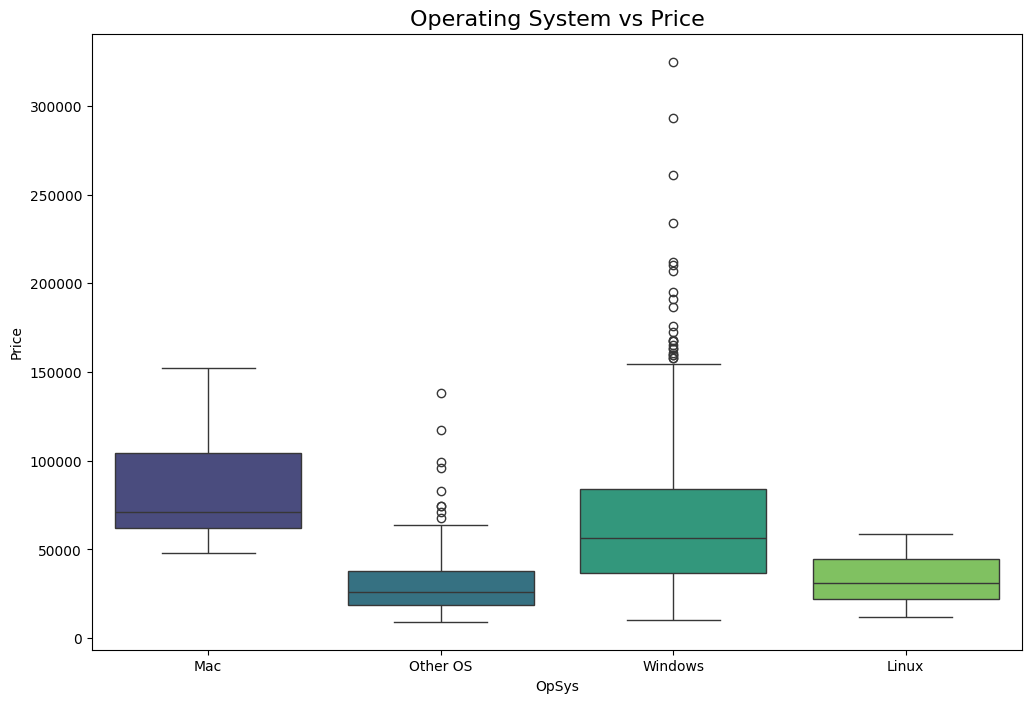

In [145]:
# Box Graph
plt.figure(figsize=(12,8))

sns.boxplot(data=data, x="OpSys", y= "Price", hue="OpSys", palette="viridis")
plt.title("Operating System vs Price", fontsize=16)

plt.show()

In [147]:
data.head()

,Company,TypeName,Inches,Ram,OpSys,Weight,Price,PPI,CPU_Brand,SSD,HDD,Gpu_Brand
0,Apple,Ultrabook,13.3,8,Mac,1.37,71378.6832,226.983005,Intel Core i5,128,0,Intel
1,Apple,Ultrabook,13.3,8,Mac,1.34,47895.5232,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,15.6,8,Other OS,1.86,30636.0000,141.211998,Intel Core i5,256,0,Intel
3,Apple,Ultrabook,15.4,16,Mac,1.83,135195.3360,220.534624,Intel Core i7,512,0,AMD
4,Apple,Ultrabook,13.3,8,Mac,1.37,96095.8080,226.983005,Intel Core i5,256,0,Intel


### Machine Learning Models

In [99]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   - -------------------------------------- 2.4/72.0 MB 14.8 MB/s eta 0:00:05
   - -------------------------------------- 2.9/72.0 MB 10.4 MB/s eta 0:00:07
   --- ------------------------------------ 5.5/72.0 MB 9.3 MB/s eta 0:00:08
   ----- ---------------------------------- 10.2/72.0 MB 12.9 MB/s eta 0:00:05
   -------- ------------------------------- 15.7/72.0 MB 15.5 MB/s eta 0:00:04
   ------------ --------------------------- 23.1/72.0 MB 18.7 MB/s eta 0:00:03
   ---------------- ----------------------- 30.1/72.0 MB 20.7 MB/s eta 0:00:03
   -------------------- ------------------- 36.7/72.0 MB 22.1 MB/s eta 0:00:02
   ------------------------ --------------- 43.5/72.0 MB 23.1 MB/s eta 0:00:02
   ---------------------------- ----------- 51.1/72.0 MB 24.4 MB/s eta 0:00:01
   -------------------------------- ------- 58.7/72.0 MB 25.4 MB/s eta 0:00:01
   ------------------------------------ --- 65.5/72.0 MB 26.1 MB/


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [100]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

Train Test Split

In [ ]:
test = np.log(data["Price"])
train = data.drop(columns=["Price"], axis=1)    # Create the train data

In [101]:
X_train, X_test, y_train, y_test = train_test_split(train, test, test_size=0.2, random_state=2)
X_train.shape, X_test.shape

((1018, 12), (255, 12))

In [ ]:
colu = {i:value for i, value in enumerate(X_train.columns)}
colu

{0: 'Company',
 1: 'TypeName',
 2: 'Inches',
 3: 'Ram',
 4: 'OpSys',
 5: 'Weight',
 6: 'Weigth',
 7: 'PPI',
 8: 'CPU_Brand',
 9: 'SSD',
 10: 'HDD',
 11: 'Gpu_Brand'}

##### Linear Regression

In [156]:
# Convert categorical variables to numerical variables
categorical_columns = [0, 1, 4, 8, 11]
prepocessor = ColumnTransformer(transformers=[
            ("col_tnf", OneHotEncoder(drop="first"), categorical_columns)], remainder="passthrough")

model_1 = LinearRegression()

pipe1 = Pipeline(steps=[("preprocessor", prepocessor), ("model_1", model_1)])

pipe1.fit(X_train, y_train)

y_pred = pipe1.predict(X_test)

print("MAE:", metrics.mean_absolute_error(y_test, y_pred), 
      "MSE:", metrics.mean_squared_error(y_test, y_pred), 
      "RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)), 
      "R2 Score:", metrics.r2_score(y_test, y_pred))

MAE: 0.20767214027784664 MSE: 0.07067366403426048 RMSE: 0.2658451880968705 R2 Score: 0.7963012084703202


##### Ridge Regression

In [ ]:
modelo_2 = Ridge(alpha=10)

pipe2 = Pipeline(steps=[("preprocessor", prepocessor), ("modelo_2", modelo_2)])
pipe2.fit(X_train, y_train)
y_pred2 = pipe2.predict(X_test)

print("MAE:", metrics.mean_absolute_error(y_test, y_pred2), 
      "MSE:", metrics.mean_squared_error(y_test, y_pred2),
      "RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred2)),
      "R2 Score:", metrics.r2_score(y_test, y_pred2))

MAE: 0.2093310412196194 MSE: 0.0688160737321302 RMSE: 0.26232817944729114 R2 Score: 0.8016552382191918
MAE: 1.232853056163904


##### Lasso Regression

In [153]:
modelo_3 = Lasso(alpha=0.001)

pipe3 = Pipeline(steps=[("preprocessor", prepocessor), ("modelo_3", modelo_3)])
pipe3.fit(X_train, y_train)
y_pred3 = pipe3.predict(X_test)

print("MAE:", metrics.mean_absolute_error(y_test, y_pred3),
      "MSE:", metrics.mean_squared_error(y_test, y_pred3),
      "RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred3)),
      "R2 Score:", metrics.r2_score(y_test, y_pred3))

MAE: 0.20783254466733633 MSE: 0.06823192855919734 RMSE: 0.2612124203769747 R2 Score: 0.8033388875308596


##### Decision Tree

In [154]:
model_4 = DecisionTreeRegressor(max_depth=8)

pipe4 = Pipeline(steps=[("preprocessor", prepocessor), ("model_4", model_4)])
pipe4.fit(X_train, y_train)
y_pred4 = pipe4.predict(X_test)

print("MAE:", metrics.mean_absolute_error(y_test, y_pred4),
      "MSE:", metrics.mean_squared_error(y_test, y_pred4),
      "RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred4)),
      "R2 Score:", metrics.r2_score(y_test, y_pred4))

MAE: 0.21559825457817125 MSE: 0.0796557166706664 RMSE: 0.2822334435722783 R2 Score: 0.7704127351260641


##### Random Forest

In [161]:
model_5 = RandomForestRegressor(n_estimators=100,
                                max_depth=15,
                                max_samples=0.5,
                                max_features=0.75,
                                random_state=3)

pipe = Pipeline(steps=[("preprocessor", prepocessor), ("model_5", model_5)])
pipe.fit(X_train, y_train)
y_pred5 = pipe.predict(X_test)

print("MAE:", metrics.mean_absolute_error(y_test, y_pred5),
        "MSE:", metrics.mean_squared_error(y_test, y_pred5),
        "RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred5)),
        "R2 Score:", metrics.r2_score(y_test, y_pred5))

MAE: 0.16874350026506596 MSE: 0.049247947421949136 RMSE: 0.22191878564454415 R2 Score: 0.8580553659945357
